<a href="https://colab.research.google.com/github/Krumca97/ZSU/blob/main/FML_Hands_on_Clustering_Credit_Cards.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hands-on clustering exercise on Credit Card Data

## The goal of this excercise is to complete the hands-on experience task with similar task description as the project has.

**Dataset**

Dataset downloaded for download is here https://www.kaggle.com/arjunbhasin2013/ccdata

And also here: https://raw.githubusercontent.com/jplatos/Fundamentals-of-Machine-Learning/refs/heads/main/CCGENERAL.csv

**Context**

This case requires to develop a customer segmentation to define marketing strategy. The sample Dataset summarizes the usage behavior of about 9000 active credit card holders during the last 6 months. The file is at a customer level with 18 behavioral variables.

**Content**

* CUSTID : Identification of Credit Card holder (Categorical)
* BALANCE : Balance amount left in their account to make purchases
* BALANCEFREQUENCY : How frequently the Balance is updated, score between 0 and 1 (1 = frequently updated, 0 = not frequently updated)
* PURCHASES : Amount of purchases made from account
* ONEOFFPURCHASES : Maximum purchase amount done in one-go
* INSTALLMENTSPURCHASES : Amount of purchase done in installment
* CASHADVANCE : Cash in advance given by the user
* PURCHASESFREQUENCY : How frequently the Purchases are being made, score between 0 and 1 (1 = frequently purchased, 0 = not frequently purchased)
* ONEOFFPURCHASESFREQUENCY : How frequently Purchases are happening in one-go (1 = frequently purchased, 0 = not frequently purchased)
* PURCHASESINSTALLMENTSFREQUENCY : How frequently purchases in installments are being done (1 = frequently done, 0 = not frequently done)
* CASHADVANCEFREQUENCY : How frequently the cash in advance being paid
* CASHADVANCETRX : Number of Transactions made with "Cash in Advanced"
* PURCHASESTRX : Numbe of purchase transactions made
* CREDITLIMIT : Limit of Credit Card for user
* PAYMENTS : Amount of Payment done by user
* MINIMUM_PAYMENTS : Minimum amount of payments made by user
* PRCFULLPAYMENT : Percent of full payment paid by user
* TENURE : Tenure of credit card service for user


# Goal of the exercises


1. Load the data from as shown in the link bellow.
2. Made the explorative analysis on the data.
3. Evaluate the missing values, scale of the data.
4. Apply k-means or aglomerative clustering and chose the propriate number of clusters.
5. Describe the clusters and their difference.





In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/jplatos/Fundamentals-of-Machine-Learning/refs/heads/main/CCGENERAL.csv")
df

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.00,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8945,C19186,28.493517,1.000000,291.12,0.00,291.12,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,325.594462,48.886365,0.500000,6
8946,C19187,19.183215,1.000000,300.00,0.00,300.00,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,275.861322,NaN,0.000000,6
8947,C19188,23.398673,0.833333,144.40,0.00,144.40,0.000000,0.833333,0.000000,0.666667,0.000000,0,5,1000.0,81.270775,82.418369,0.250000,6
8948,C19189,13.457564,0.833333,0.00,0.00,0.00,36.558778,0.000000,0.000000,0.000000,0.166667,2,0,500.0,52.549959,55.755628,0.250000,6


In [3]:
print("-------- INFO --------")
print(df.info())
# DESCRIBE
print("-------- DESCRIBE --------")
print(df.describe())

-------- INFO --------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-nul

In [4]:
df.isna().sum().sort_values(ascending=False)

,0
MINIMUM_PAYMENTS,313
CREDIT_LIMIT,1
BALANCE,0
CUST_ID,0
BALANCE_FREQUENCY,0
PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0


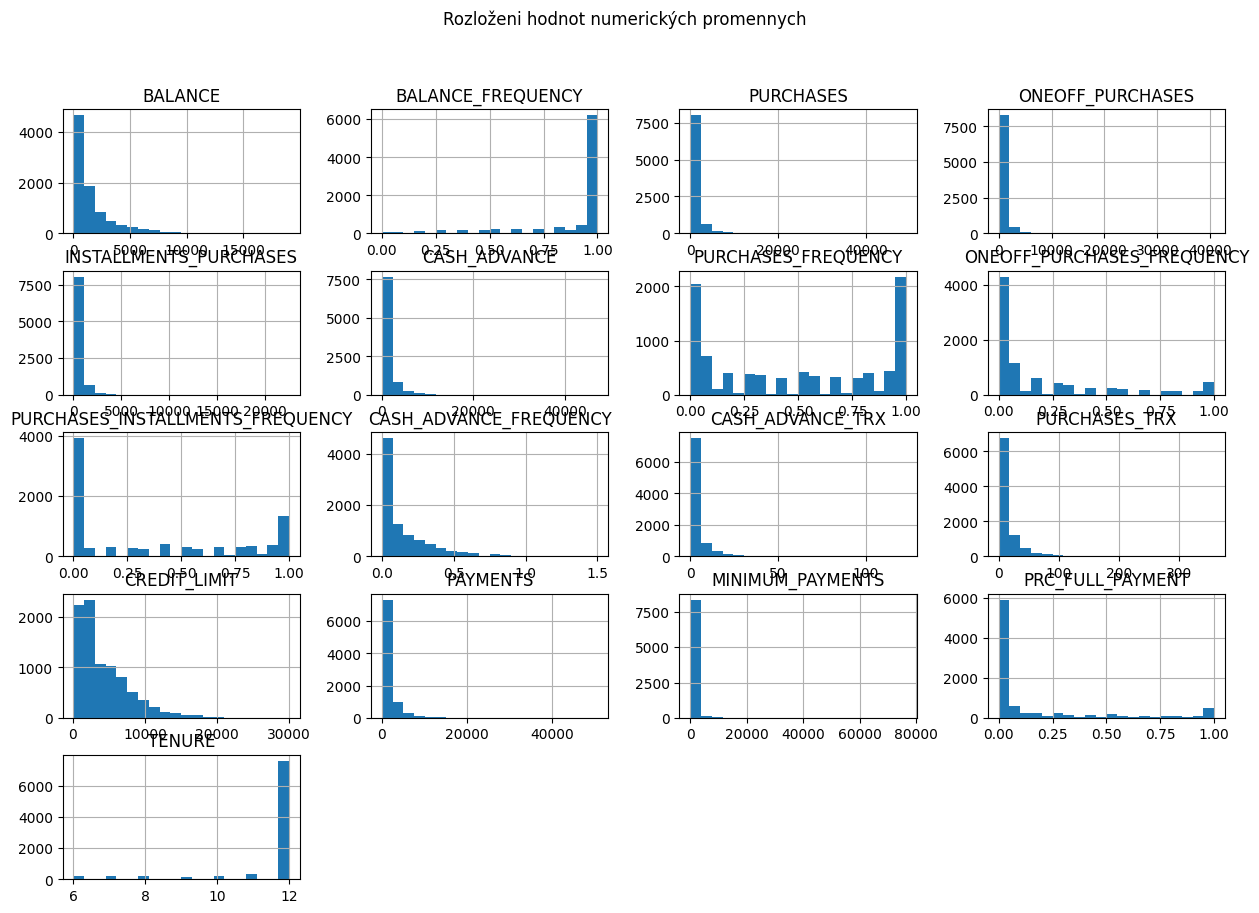

In [5]:
df.hist(figsize=(15,10), bins=20)
plt.suptitle("Rozloženi hodnot numerických promennych")
plt.show()

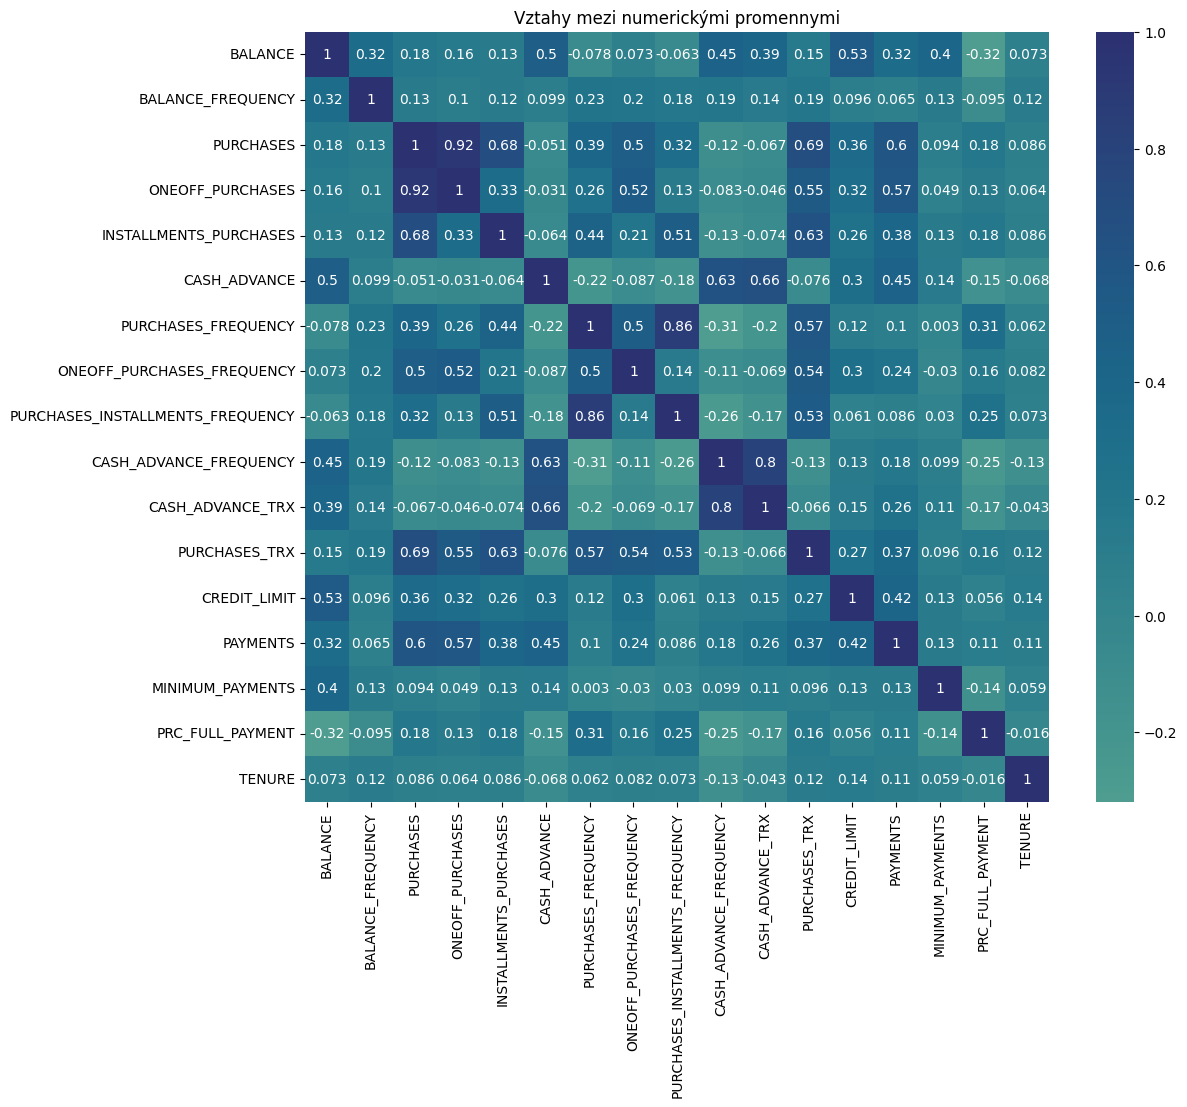

In [6]:
plt.figure(figsize=(12,10))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), cmap="crest", center=0, annot=True)
plt.title("Vztahy mezi numerickými promennymi")
plt.show()

In [7]:
df.columns

Index(['CUST_ID', 'BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES',
       'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE',
       'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY',
       'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY',
       'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS',
       'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE'],
      dtype='object')

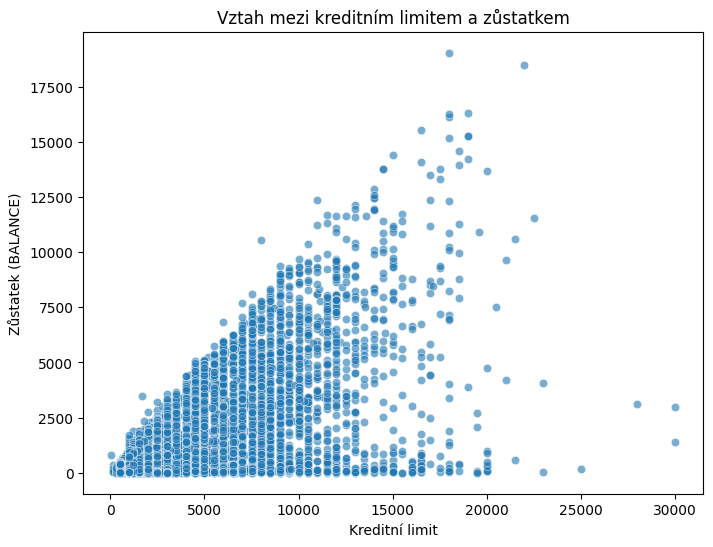

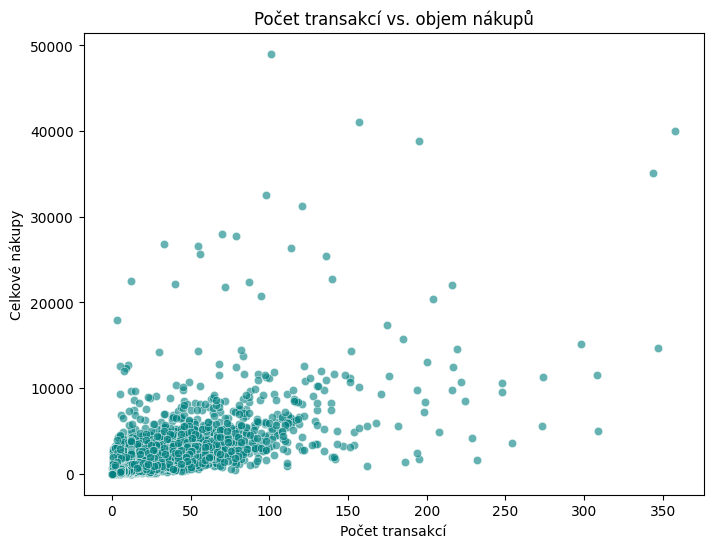

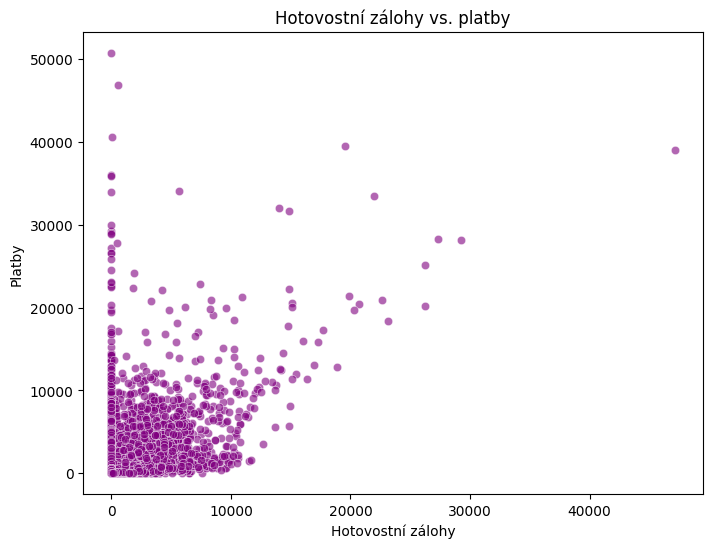

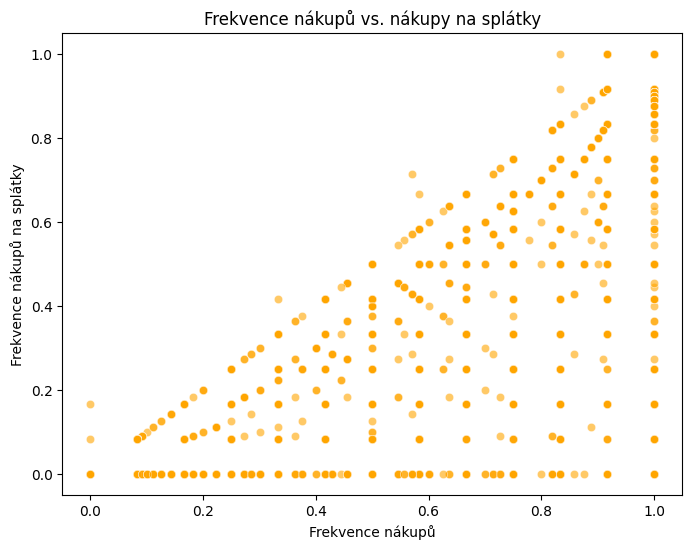

In [8]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='CREDIT_LIMIT', y='BALANCE', alpha=0.6)
plt.title('Vztah mezi kreditním limitem a zůstatkem')
plt.xlabel('Kreditní limit')
plt.ylabel('Zůstatek (BALANCE)')
plt.show()

plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='PURCHASES_TRX', y='PURCHASES', alpha=0.6, color='teal')
plt.title('Počet transakcí vs. objem nákupů')
plt.xlabel('Počet transakcí')
plt.ylabel('Celkové nákupy')
plt.show()

plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='CASH_ADVANCE', y='PAYMENTS', alpha=0.6, color='purple')
plt.title('Hotovostní zálohy vs. platby')
plt.xlabel('Hotovostní zálohy')
plt.ylabel('Platby')
plt.show()

plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='PURCHASES_FREQUENCY', y='PURCHASES_INSTALLMENTS_FREQUENCY', alpha=0.6, color='orange')
plt.title('Frekvence nákupů vs. nákupy na splátky')
plt.xlabel('Frekvence nákupů')
plt.ylabel('Frekvence nákupů na splátky')
plt.show()


In [10]:
df['CREDIT_LIMIT'] = df['CREDIT_LIMIT'].fillna(df['CREDIT_LIMIT'].median())
df['MINIMUM_PAYMENTS'] = df['MINIMUM_PAYMENTS'].fillna(df['MINIMUM_PAYMENTS'].median())


In [11]:
from sklearn.preprocessing import PowerTransformer

X = df.select_dtypes(include=[np.number])

X = X.fillna(X.median())

pt = PowerTransformer(method='yeo-johnson')
X_transformed = pt.fit_transform(X)

df_scaled = pd.DataFrame(X_transformed, columns=X.columns)
df_scaled.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,-1.238103,-1.079348,-0.368050,-1.000488,0.383704,-0.944538,-0.766859,-0.903315,-0.606642,-0.883204,-0.905801,-0.573664,-1.425353,-0.983876,-0.824388,-0.677889,0.422252
1,1.051961,-0.424939,-1.505149,-1.000488,-1.085422,1.399909,-1.278866,-0.903315,-1.004445,1.124423,1.044342,-1.387624,0.924217,1.285321,0.917393,1.235021,0.422252
2,0.860616,0.628612,0.521657,1.065381,-1.085422,-0.944538,1.218860,1.732554,-1.004445,-0.883204,-0.905801,0.494757,1.012194,-0.291722,0.475906,-0.677889,0.422252
3,0.570542,-1.710851,0.875823,1.229556,-1.085422,0.680451,-1.015926,-0.092230,-1.004445,0.136071,0.194580,-0.872718,1.012194,-2.782085,-0.115812,-0.677889,0.422252
4,0.111925,0.628612,-0.904786,-0.019902,-1.085422,-0.944538,-1.015926,-0.092230,-1.004445,-0.883204,-0.905801,-0.872718,-1.215705,-0.231669,-0.327305,-0.677889,0.422252


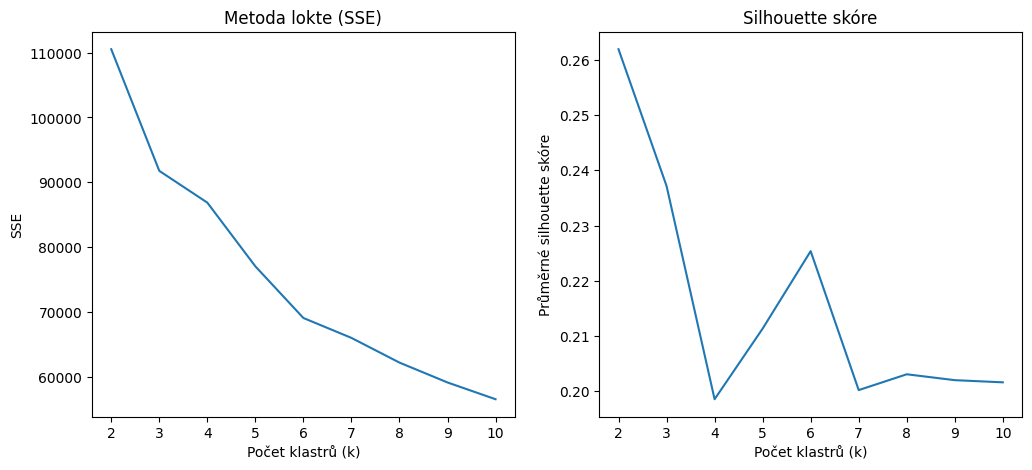

In [12]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X_values = df_scaled.values

sse = []          # součet čtverců vzdáleností v klastrech
silhouette = []   # průměrné silhouette skóre
K = range(2, 11)  # zkoušíme od 2 do 10 klastrů

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_values)
    sse.append(kmeans.inertia_)  # metrika z K-Means (SSE)
    silhouette.append(silhouette_score(X_values, kmeans.labels_))

# vizualizace
fig, ax = plt.subplots(1, 2, figsize=(12,5))

sns.lineplot(x=K, y=sse, ax=ax[0])
ax[0].set_title('Metoda lokte (SSE)')
ax[0].set_xlabel('Počet klastrů (k)')
ax[0].set_ylabel('SSE')

sns.lineplot(x=K, y=silhouette, ax=ax[1])
ax[1].set_title('Silhouette skóre')
ax[1].set_xlabel('Počet klastrů (k)')
ax[1].set_ylabel('Průměrné silhouette skóre')

plt.show()


In [13]:
from sklearn.cluster import KMeans

# spustíme K-Means s 6 klastrami
kmeans_final = KMeans(n_clusters=6, random_state=42)
df_scaled['cluster_id'] = kmeans_final.fit_predict(df_scaled)

df_scaled['cluster_id'].value_counts().sort_index()

,count
cluster_id,
0,1452
1,634
2,1974
3,2001
4,1529
5,1360


In [14]:
cluster_summary = df_scaled.groupby('cluster_id').mean()
cluster_summary

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
cluster_id,,,,,,,,,,,,,,,,,
0,0.827226,0.462007,0.669864,0.597004,0.538613,1.069721,0.612391,0.592391,0.487113,1.044409,1.076882,0.713604,0.367928,0.573245,0.754136,-0.343157,0.111476
1,0.206400,-0.518127,-1.056814,-0.604950,-0.922975,1.039660,-0.999182,-0.582490,-0.864320,1.051156,0.953774,-1.072750,-0.379493,-0.440214,-0.085005,-0.356945,-2.353601
2,-0.942836,-0.384983,0.156770,-0.842940,0.781809,-0.897377,0.596640,-0.800148,0.860110,-0.849113,-0.868640,0.329595,-0.443371,-0.520282,-0.600652,0.606653,0.000546
3,0.515505,0.225895,-1.266379,-0.757061,-1.023968,0.997227,-1.200109,-0.750963,-0.972733,0.919142,0.966688,-1.239237,-0.057575,0.043888,0.373272,-0.400207,0.417564
4,0.123665,0.427351,1.110477,1.085105,0.918236,-0.881431,0.984717,1.176229,0.826619,-0.840053,-0.858438,1.142325,0.571510,0.634771,0.006581,0.396601,0.291776
5,-0.508411,-0.505750,0.164719,0.762063,-0.805305,-0.800514,-0.395361,0.582987,-0.863696,-0.780535,-0.790751,-0.201141,-0.130183,-0.429855,-0.450297,-0.204820,0.034978


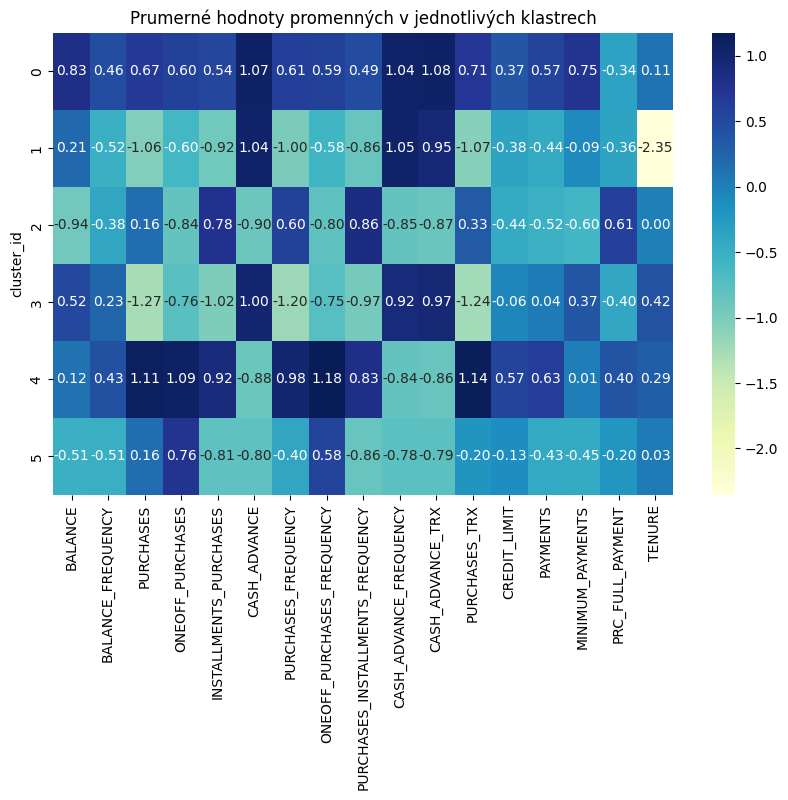

In [15]:
plt.figure(figsize=(10,6))
sns.heatmap(cluster_summary, cmap='YlGnBu', annot=True, fmt=".2f")
plt.title('Prumerné hodnoty promenných v jednotlivých klastrech')
plt.show()

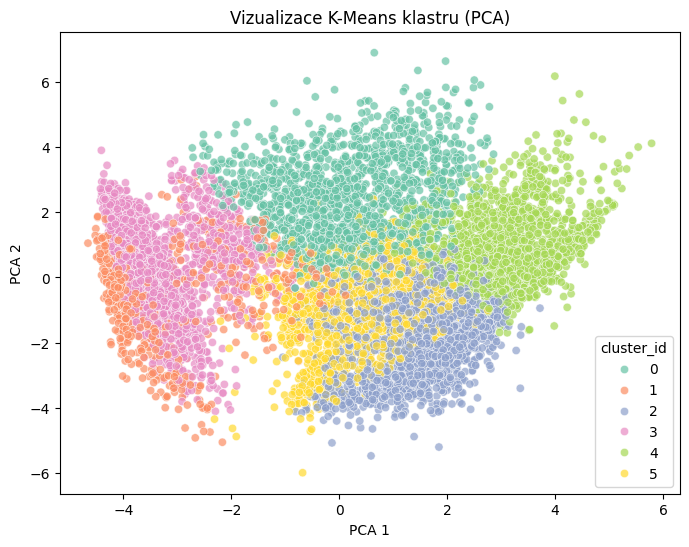

In [16]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_result = pca.fit_transform(df_scaled.drop('cluster_id', axis=1))

plt.figure(figsize=(8,6))
sns.scatterplot(x=pca_result[:,0], y=pca_result[:,1],
                hue=df_scaled['cluster_id'], palette='Set2', alpha=0.7)
plt.title('Vizualizace K-Means klastru (PCA)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.show()

In [17]:
df_scaled['cluster_id'].value_counts().sort_index()

,count
cluster_id,
0,1452
1,634
2,1974
3,2001
4,1529
5,1360


In [18]:
cluster_summary.head()


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
cluster_id,,,,,,,,,,,,,,,,,
0,0.827226,0.462007,0.669864,0.597004,0.538613,1.069721,0.612391,0.592391,0.487113,1.044409,1.076882,0.713604,0.367928,0.573245,0.754136,-0.343157,0.111476
1,0.206400,-0.518127,-1.056814,-0.604950,-0.922975,1.039660,-0.999182,-0.582490,-0.864320,1.051156,0.953774,-1.072750,-0.379493,-0.440214,-0.085005,-0.356945,-2.353601
2,-0.942836,-0.384983,0.156770,-0.842940,0.781809,-0.897377,0.596640,-0.800148,0.860110,-0.849113,-0.868640,0.329595,-0.443371,-0.520282,-0.600652,0.606653,0.000546
3,0.515505,0.225895,-1.266379,-0.757061,-1.023968,0.997227,-1.200109,-0.750963,-0.972733,0.919142,0.966688,-1.239237,-0.057575,0.043888,0.373272,-0.400207,0.417564
4,0.123665,0.427351,1.110477,1.085105,0.918236,-0.881431,0.984717,1.176229,0.826619,-0.840053,-0.858438,1.142325,0.571510,0.634771,0.006581,0.396601,0.291776


<Figure size 1000x600 with 0 Axes>

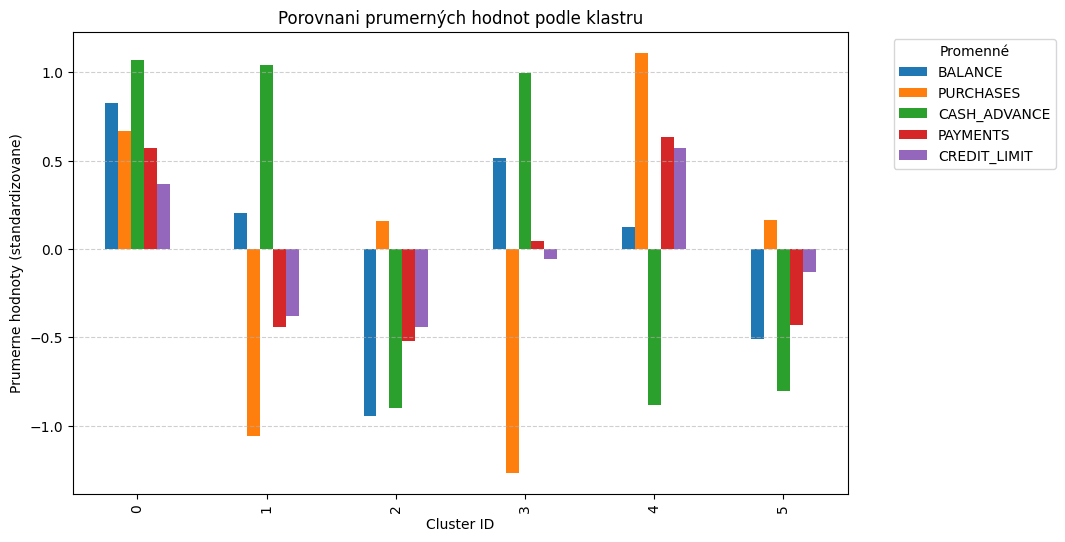

In [20]:
selected_features = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'PAYMENTS', 'CREDIT_LIMIT']

plt.figure(figsize=(10,6))
cluster_summary[selected_features].plot(kind='bar', figsize=(10,6))
plt.title("Porovnani prumerných hodnot podle klastru")
plt.xlabel("Cluster ID")
plt.ylabel("Prumerne hodnoty (standardizovane)")
plt.legend(title="Promenné", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()